In [1]:
from TKA_JGA_Mo_250111_EoS_3 import calc_eq, dfg, phi_Soave, delta_f_G, phi_Soave_3, element_balance
import numpy as np
import matplotlib.pyplot as plt

## Alvarez 2017: here also these jumps seeable

In [2]:
x_0 = np.array([
    0.08, # CO2
    0.74-2e-20, # H2
    1e-20, # H2O
    0.15, # CO
    1e-20,
    0.03,
])

x_1 = np.array([
    0.25, # CO2
    0.75, # H2
    0, # H2O
    0,
    0,
    0,
])

x = np.vstack([x_0, x_1])

In [3]:
x.shape

(2, 6)

# SI compostion

In [4]:
T = np.linspace(100, 400, 30) + 273.15
#T = np.array([400]) + 273.15 # K
p = np.array(([100])) * 1e5
x_0_G = np.array([
    0.08, # CO2
    0.74-2e-20, # H2
    1e-20, # H2O
    0.15, # CO
    1e-20,
    0.03,
])

x_0_L = np.array([
    1e-20, # H2O
    1e-20, # MeOH
    1e-20, # H2O
    1e-20,
    1e-20,
    1e-20,
    #0,
    #0,
])

In [5]:
T = np.linspace(100, 400, 5) + 273.15
#T = np.array([400]) + 273.15 # K
p = np.array(([100])) * 1e5
x_0_G = np.array([
    0.25, # CO2
    0.75-4e-20, # H2
    1e-20, # H2O
    1e-20, # CO
    1e-20,
    1e-20,
])

x_0_L = np.array([
    1e-20, # H2O
    1e-20, # MeOH
    1e-20, # H2O
    1e-20,
    1e-20,
    1e-20,
    #0,
    #0,
])

In [6]:
x_0 = np.hstack([x_0_G, x_0_L])
x_0.shape

(12,)

# gE-Modell

In [7]:
'''counter = 0
x_eq = np.zeros((len(p), len(T), x_0_G.shape[0]))
#x_G_eq = np.zeros((len(p), len(T), x_0_G.shape[0]))
#x_L_eq = np.zeros((len(p), len(T), x_0_L.shape[0]))
X_CO2 = np.zeros((len(p), len(T)))
S_MeOH = np.zeros((len(p), len(T)))
for i in range(len(p)):
    for j in range(len(T)):
        x_eq[i, j, :], succ, g_T_val, n_eq_val = calc_eq(T[j], p[i], x_0_G, 'real gas')
        #x_G_eq[i, j, :] = x_eq[i, j, :6]
        #x_L_eq[i, j, :] = x_eq[i, j, 6:]
        X_CO2[i, j] = (x_0[0] - n_eq_val[0]) / x_0[0]
        S_MeOH[i, j] = - ((x_0[4] + x_0[-1]) - (n_eq_val[4] + n_eq_val[-1])) / (x_0[0] - n_eq_val[0])'''

"counter = 0\nx_eq = np.zeros((len(p), len(T), x_0_G.shape[0]))\n#x_G_eq = np.zeros((len(p), len(T), x_0_G.shape[0]))\n#x_L_eq = np.zeros((len(p), len(T), x_0_L.shape[0]))\nX_CO2 = np.zeros((len(p), len(T)))\nS_MeOH = np.zeros((len(p), len(T)))\nfor i in range(len(p)):\n    for j in range(len(T)):\n        x_eq[i, j, :], succ, g_T_val, n_eq_val = calc_eq(T[j], p[i], x_0_G, 'real gas')\n        #x_G_eq[i, j, :] = x_eq[i, j, :6]\n        #x_L_eq[i, j, :] = x_eq[i, j, 6:]\n        X_CO2[i, j] = (x_0[0] - n_eq_val[0]) / x_0[0]\n        S_MeOH[i, j] = - ((x_0[4] + x_0[-1]) - (n_eq_val[4] + n_eq_val[-1])) / (x_0[0] - n_eq_val[0])"

# Equation of State

In [8]:
counter = 0
x_eq = np.zeros((len(p), len(T), x_0.shape[0]))
x_G_eq = np.zeros((len(p), len(T), x_0_G.shape[0]))
n_eq = np.zeros((len(p), len(T), x_0.shape[0]))
x_L_eq = np.zeros((len(p), len(T), x_0_L.shape[0]))
X_CO2 = np.zeros((len(p), len(T)))
S_MeOH = np.zeros((len(p), len(T)))
for i in range(len(p)):
    for j in range(len(T)):
        #x_eq[i, j, :], succ, g_T_val, n_eq_val = calc_eq(T[j], p[i], x_0, 'ideal gas')
        _, _, n_eq[i, j, :] = calc_eq(T[j], p[i], x_0, 'real gas')
        #x_G_eq[i, j, :] = x_eq[i, j, :6]
        #x_L_eq[i, j, :] = x_eq[i, j, 6:]
        X_CO2[i, j] = ((x_0[0] + x_0[6]) - (n_eq[i, j, 0] + n_eq[i, j, 6])) / (x_0[0] + x_0[6])
        S_MeOH[i, j] = ((n_eq[i, j, 4] + n_eq[i, j, 10]) - (x_0[4] + x_0[10])) / ((x_0[0] + x_0[6]) - (n_eq[i, j, 0] + n_eq[i, j, 6]))
        #S_MeOH[i, j] = - ((x_0[4] + x_0[-1]) - (n_eq_val[4] + n_eq_val[-1])) / (x_0[0] - n_eq_val[0])
        #X_CO2[i, j] = ((x_0[0]) - (n_eq[i, j, 0])) / (x_0[0])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/Users/johannesgeri/Documents/Master/HiWi/ANNs/gibbsenergyminimizationmodel/TKA_Mo_fug_coeffs_MeOH.py:209: RuntimeWarning: invalid value encountered in log
  res_liq = np.exp(ratio_b_liq * (Z_liq - 1) - np.log(Z_liq - B_L) - A_L / B_L * (2 * ratio_a_liq - ratio_b_liq) * np.log(1 + B_L / Z_liq)) # array of fugacity coefficients in 1


# Calculation of isofugacity condition

In [9]:
n_G_eq = n_eq[:, :, :6]
n_L_eq = n_eq[:, :, 6:]
x_G_eq = n_G_eq / np.sum(n_G_eq, axis=2)[:, :, np.newaxis]
x_L_eq = n_L_eq / np.sum(n_L_eq, axis=2)[:, :, np.newaxis]

In [10]:
print("gas phase composition")
print("CO2:", x_G_eq[0, 0, 0])
print("H2:", x_G_eq[0, 0, 1])
print("H2O:", x_G_eq[0, 0, 2])
print("CO:", x_G_eq[0, 0, 3])
print("MeOH:", x_G_eq[0, 0, 4])
print("N2:", x_G_eq[0, 0, 5])
print("vapor phase fraction:", np.sum(n_G_eq[0, 0]) / np.sum(n_eq[0, 0]))

gas phase composition
CO2: 0.283934246387391
H2: 0.00025982123806411625
H2O: 0.5657847906988867
CO: 0.019273062256006706
MeOH: 0.13074807941965144
N2: 3.646581907409522e-21
vapor phase fraction: 0.5801044060222366


In [11]:
print("liquid phase composition")
print("CO2:", x_L_eq[0, 0, 0])
print("H2:", x_L_eq[0, 0, 1])
print("H2O:", x_L_eq[0, 0, 2])
print("CO:", x_L_eq[0, 0, 3])
print("MeOH:", x_L_eq[0, 0, 4])
print("N2:", x_L_eq[0, 0, 5])
print("liquid phase fraction:", np.sum(n_L_eq[0, 0]) / np.sum(n_eq[0, 0]))

liquid phase composition
CO2: 0.39222016731163617
H2: 6.036166806278384e-06
H2O: 0.3925703695452
CO: 0.062128372288509606
MeOH: 0.15307505468784774
N2: 2.6352534766824884e-20
liquid phase fraction: 0.4198955939777635


In [12]:
phi_L = np.zeros((len(p), len(T), x_0_L.shape[0]))
phi_G = np.zeros((len(p), len(T), x_0_G.shape[0]))

In [13]:
for i, pp in enumerate(p):
    for j, TT in enumerate(T):
        z = np.hstack([x_G_eq[i, j, :], x_L_eq[i, j, :]])
        phi_L[i, j, :], phi_G[i, j, :], _ = phi_Soave_3(z, T[j], p[i])

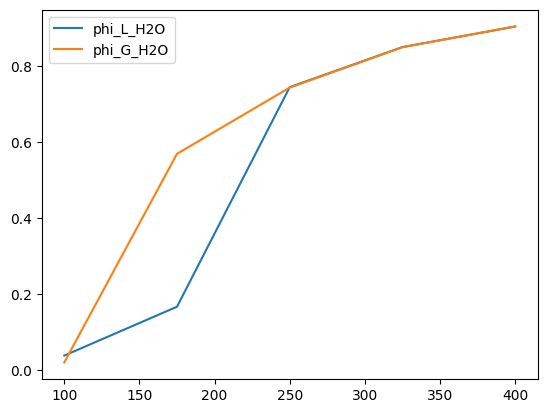

In [14]:
# plot phi_L and phi_G vs T
plt.figure()
#plt.plot(T-273.15, phi_L[0, :, 4], label='phi_L_MeOH')
#plt.plot(T-273.15, phi_G[0, :, 4], label='phi_G_MeOH')
#plt.plot(T-273.15, phi_L[0, :, 0], label='phi_L_CO2')
#plt.plot(T-273.15, phi_G[0, :, 0], label='phi_G_CO2')
#plt.plot(T-273.15, phi_L[0, :, 1], label='phi_L_H2')
#plt.plot(T-273.15, phi_G[0, :, 1], label='phi_G_H2')
plt.plot(T-273.15, phi_L[0, :, 2], label='phi_L_H2O')
plt.plot(T-273.15, phi_G[0, :, 2], label='phi_G_H2O')
plt.legend()
plt.show()

In [15]:
print(phi_G[0, 0, 0] * x_G_eq[0, 0, 0])

1.2275582089937747


In [16]:
print(phi_L[0, 0, 0]*x_L_eq[0, 0, 0])

0.8410487207288119


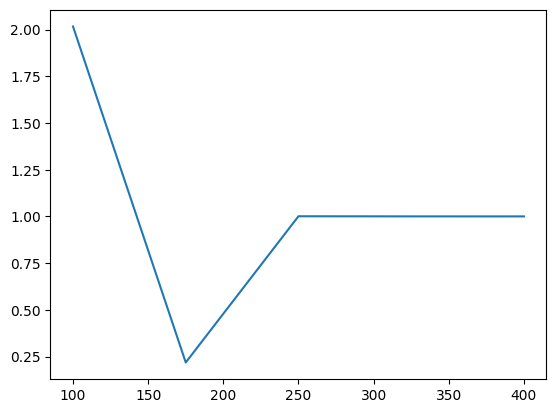

In [17]:
plt.plot(T[:8]-273.15, phi_G[0, :, 0] / phi_L[0, :, 0], label='CO2')

In [18]:
# now check fugacity of liquid vs gas
fug_L = np.zeros((len(p), len(T), x_0_L.shape[0]))
fug_G = np.zeros((len(p), len(T), x_0_G.shape[0]))

for i, pp in enumerate(p):
    for j, TT in enumerate(T):
        fug_L[i, j, :] = phi_L[i, j, :] * p[i] * x_L_eq[i, j, :]
        fug_G[i, j, :] = phi_G[i, j, :] * p[i] * x_G_eq[i, j, :]

In [19]:
# relative fugacity deviation
delta_fug = np.zeros((len(p), len(T), x_0_G.shape[0]))

for i, pp in enumerate(p):
    for j, TT in enumerate(T):
        delta_fug[i, j, :] = (fug_L[i, j, :] - fug_G[i, j, :]) / fug_G[i, j, :] * 100

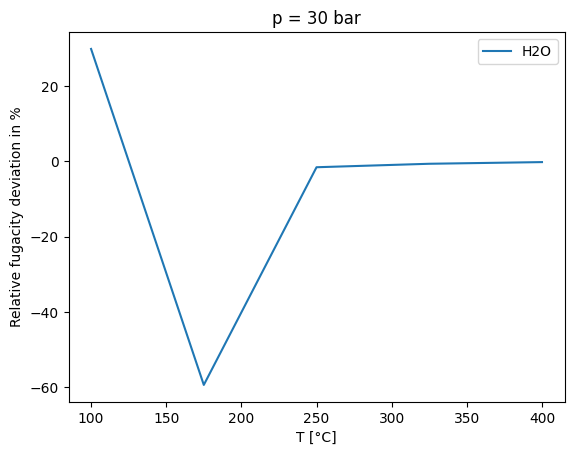

In [20]:
# plot relative deviation for MeOH and H2O vs T
fig, ax = plt.subplots()

#plt.plot(T-273.15, delta_fug[0, :, 4], label='MeOH')
plt.plot(T-273.15, delta_fug[0, :, 2], label='H2O')
#plt.plot(T-273.15, delta_fug[2, :, 5], label='N2')
#plt.plot(T-273.15, delta_fug[0, :, 3], label='CO')
plt.title('p = 30 bar')
plt.xlabel('T [°C]')
plt.ylabel('Relative fugacity deviation in %')
plt.legend()
# set y axis to log scale
#plt.yscale('log')
plt.show()

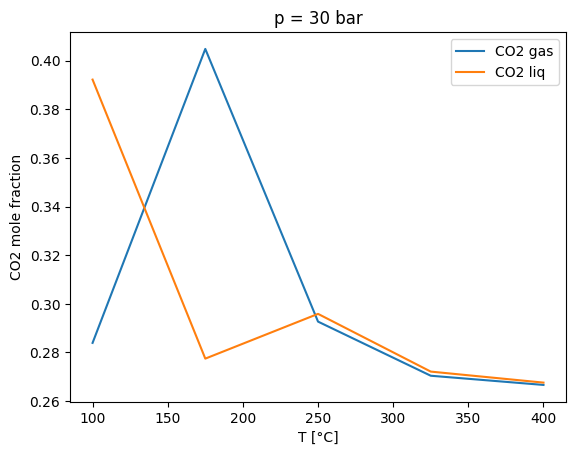

In [21]:
# plot co2 mole fraction vs T
fig, ax = plt.subplots()

plt.plot(T-273.15, x_G_eq[0, :, 0], label='CO2 gas')
plt.plot(T-273.15, x_L_eq[0, :, 0], label='CO2 liq')
plt.title('p = 30 bar')
plt.xlabel('T [°C]')
plt.ylabel('CO2 mole fraction')
plt.legend()

plt.show()

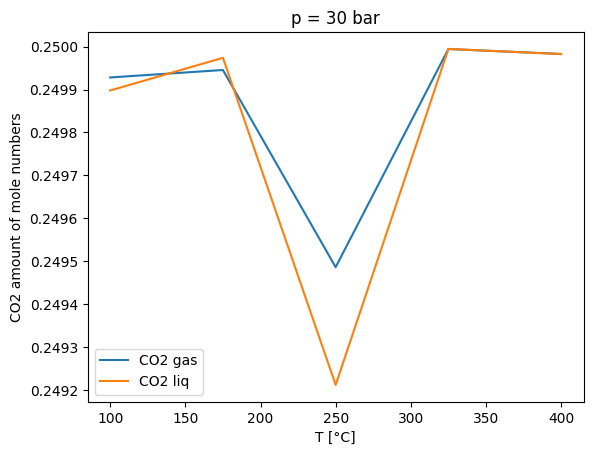

In [22]:
# plot co2 mole fraction vs T
fig, ax = plt.subplots()

plt.plot(T-273.15, n_G_eq[0, :, 0], label='CO2 gas')
plt.plot(T-273.15, n_L_eq[0, :, 0], label='CO2 liq')
plt.title('p = 30 bar')
plt.xlabel('T [°C]')
plt.ylabel('CO2 amount of mole numbers')
plt.legend()

plt.show()

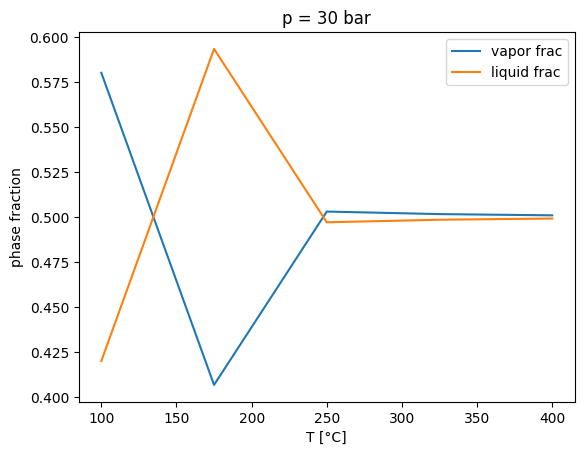

In [23]:
# plot vapor frac and liquid frac vs T
fig, ax = plt.subplots()

plt.plot(T-273.15, np.sum(n_G_eq[0, : , :], axis=1) / np.sum(n_eq[0, :, :], axis=1), label='vapor frac')
plt.plot(T-273.15, np.sum(n_L_eq[0, :, :], axis=1) / np.sum(n_eq[0, :, :], axis=1), label='liquid frac')
plt.title('p = 30 bar')
plt.xlabel('T [°C]')
plt.ylabel('phase fraction')
plt.legend()

plt.show()

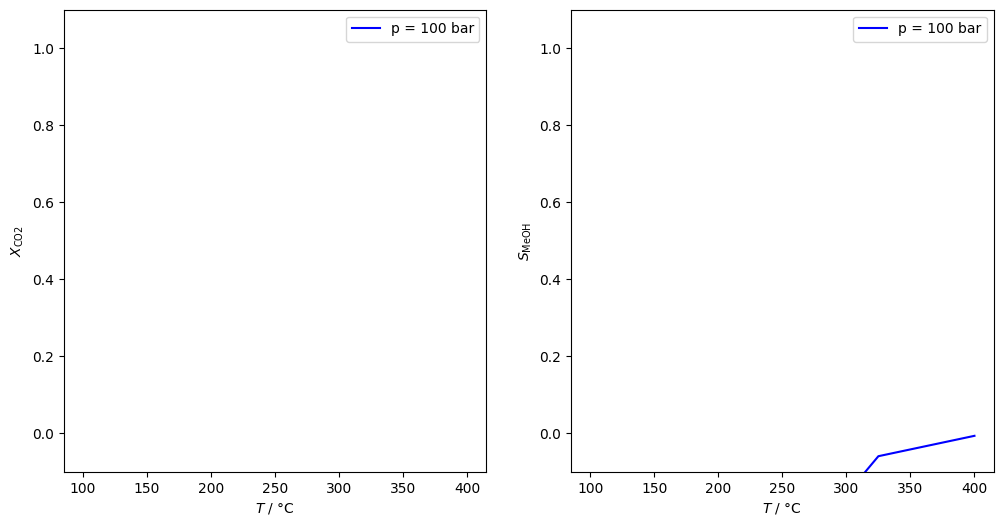

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))


species = ['CO2', 'H2', 'H2O', 'CO', 'MeOH', 'N2', 'MeOH_L', 'H2O_L']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'limegreen']

for j in range(len(p)):
    #plt.plot(T-273.15, x_eq[0, :, j], label=species[j], color=colors[j])
    # plot X_CO2
    ax[0].plot(T-273.15, X_CO2[j, :], label=f'p = {p[j]/1e5:.0f} bar', color=colors[j])
    # plot S_MeOH
    ax[1].plot(T-273.15, S_MeOH[j, :], label=f'p = {p[j]/1e5:.0f} bar', color=colors[j])

ax[0].set_xlabel(r'$T$ / °C')
ax[1].set_xlabel(r'$T$ / °C')
ax[0].set_ylim(-0.1, 1.1)
ax[1].set_ylim(-0.1, 1.1)
ax[0].set_ylabel(r'$X_{\mathrm{CO2}}$')
ax[1].set_ylabel(r'$S_{\mathrm{MeOH}}$')
ax[0].legend()
ax[1].legend()
plt.show()